# Eight-dimensional potential game with contraction

Install the package using the [project README](../README.md), then run the cells in order.

This is the eight-player version of the same potential game, with the same
parameters and all-to-all coupling among eight players. It uses the full
MMNN tangent basis by default. The snapshot graphs show four coordinate
pairs covering all eight coordinates.
The game velocity and time loop are defined in this notebook. The MMNN,
tangent construction, SVD projection, sampling, RK4 reference, and standard
plots are reused from the installed `dtb_game` package. No change to `dynamics.py`
is needed. The reference law is $z_i\sim U([-1,1]^8)$ and $X^0(z)=z$.

Each run writes a timestamped folder under `results/potential_game_8d_mmnn/`.
The final cell creates a ZIP archive of that run's numerical outputs.


In [ ]:
from pathlib import Path
import json
import os
import shutil
import socket
import sys
import time

import dtb_game

# Locate this project for numerical output.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'pyproject.toml').is_file() and (path / 'src' / 'dtb_game').is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Open this notebook from the project checkout.')

import_root = Path(dtb_game.__file__).resolve().parent
source_sha256 = None
results_root = repo_root / 'results'

import matplotlib.pyplot as plt
import numpy as np
import torch
from dtb_game.dynamics import (FunctionalGame)
from dtb_game.models import (ResidualMMNN, count_parameters)
from dtb_game.integrators import (dtb_step)
from dtb_game.projection import (evaluate_dtb_projection, evaluate_model, flat_parameters, subset_tangent_selection, project_velocity, TangentProjection)
from dtb_game.integrators import (rk4_flow)
from dtb_game.utils import (make_time_grid, paired_rms, resolve_device, resolve_dtype, sample_uniform_box, snapshot_indices, to_numpy, warmup_cuda, write_csv, write_json)
from dtb_game.plotting import (plot_cloud_snapshots, plot_configuration_diagnostics)

print("Host:", socket.gethostname())
print("Python:", sys.executable)
print("Working directory:", Path.cwd())
print("Package source:", import_root)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Results base directory:", results_root)


## Game and numerical settings

Each particle is a joint strategy $x=(x_1,\ldots,x_8)\in[-1,1]^8$. The potential is
\[
\Phi(x)=-\frac{\lambda}{2}\sum_{i=1}^{8}x_i^2
-\frac{\gamma}{2}\sum_{1\leq i<j\leq 8}(x_i-x_j)^2
+\frac{\epsilon}{\omega}\sum_{i=1}^{8}\cos(\omega x_i).
\]
The eight-player gradient-ascent dynamics are
\[
\dot{x}_i=-\lambda x_i-\gamma\left(8x_i-\sum_{j=1}^{8}x_j\right)
-\epsilon\sin(\omega x_i),\qquad i=1,\ldots,8.
\]
Use $\lambda=0.5$, $\gamma=0.2$, $\epsilon=0.5$, $\omega=4\pi$.
The sum is over players within each particle. All eight players are coupled;
the coordinate pairs used for plotting do not split the dynamics into blocks.
There is no normalization of the coupling by eight. Initial particles are
uniform in the eight-dimensional box.

`TANGENT_BASIS_SIZE=None` uses every trainable MMNN coordinate. A smaller integer
selects a subset, always including all final-layer biases so each output has an
active direction at identity initialization. `resample_each_step` redraws the
remaining coordinates reproducibly; `fixed` keeps them. The random features
$W,b$ stay frozen; only the mixing parameters $A,c$ evolve.


In [2]:
DIM = 8
LAMBDA, GAMMA, EPSILON, OMEGA = 0.5, 0.2, 0.5, 4 * np.pi
SEED = 2026
N_PARTICLES = 10000
H = 0.001
T_FINAL = 2.0
SNAPSHOT_TIMES = (0.0, 0.5, 1.0, 2.0)

MMNN_WIDTH, MMNN_RANK, MMNN_DEPTH = 24, 12, 4
ACTIVATION = "tanh"
TANGENT_BASIS_SIZE = None  # full basis, or an integer >= DIM
SUBSET_MODE = "fixed"     # "fixed" or "resample_each_step"
SVD_RTOL = 1e-3
JACOBIAN_CHUNK = 2048
DTYPE = "float64"
DEVICE = "auto"           # CUDA if available, otherwise CPU
CPU_THREADS = max(1, min(4, int(os.environ.get("SLURM_CPUS_PER_TASK", "4"))))
REFERENCE_MAX_STEP = H / 4
OUTPUT_ROOT = results_root / "potential_game_8d_mmnn"  # or an absolute project-storage path


def velocity(x, t=0.0):
    """Gradient ascent for one joint strategy per row: shape (N, 8)."""
    return (-LAMBDA * x
            - GAMMA * (DIM * x - x.sum(dim=-1, keepdim=True))
            - EPSILON * torch.sin(OMEGA * x))


def potential(x):
    # sum_{i<j}(x_i-x_j)^2 = DIM * sum_i(x_i - mean(x))^2
    pairwise_sum = DIM * (x - x.mean(dim=-1, keepdim=True)).square().sum(dim=-1)
    return (-0.5 * LAMBDA * x.square().sum(dim=-1)
            - 0.5 * GAMMA * pairwise_sum
            + (EPSILON / OMEGA) * torch.cos(OMEGA * x).sum(dim=-1))


# Notebook-local callable; no new class or configuration in games.py.
game = FunctionalGame(dim=DIM, name="potential_game_8d", velocity_fn=velocity)

# Independent check of the sign and all-to-all coupling against the potential.
check_x = sample_uniform_box(7, DIM, low=-1, high=1, dtype=torch.float64,
                             device=torch.device("cpu"), seed=SEED + 9)
check_x.requires_grad_(True)
check_gradient = torch.autograd.grad(potential(check_x).sum(), check_x)[0]
torch.testing.assert_close(velocity(check_x), check_gradient, rtol=1e-12, atol=1e-12)
print("Velocity agrees with grad(Phi).")


Velocity agrees with grad(Phi).


## Algorithm convention

The reference labels $z_i$ remain fixed and the tangent is recomputed at the
current parameter vector on those labels:
\[
J_k=\partial_{\theta_{S_k}}T_{\theta_k}(z),\quad
\alpha_k=\arg\min_a\|J_ka-v(X_k,t_k)\|_2^2,\quad
X_{k+1}=X_k+hJ_k\alpha_k.
\]
The package's `dtb_step` also updates
$\theta_{k+1,S_k}=\theta_{k,S_k}+h\alpha_k$ to adapt the next tangent basis.
The physical state is the accumulated $X_k$; evaluating the nonlinear network
$T_{\theta_k}(z)$ is a separate operation. Identity initialization is exact.

This deterministic variant uses no periodic reset/refit (equivalently $L\ge K$)
and no stochastic score update. Each `DTBSet` entry stores the pre-update
$\theta_k$, selected coordinates, $\alpha_k$, and step size, allowing evaluation
of the accumulated map on new labels. SVD diagnostics use the package's
normalization $J_k/\sqrt{N}$; multiply by $\sqrt{N}$ for $\sigma(J_k)$.

If the package's numerical SVD fails to converge, the notebook retries the
same truncated SVD with NumPy's CPU backend, using the same normalization and
cutoff. The result is transferred back to the configured PyTorch device.
This keeps the physical update and tangent basis unchanged. The number of
fallback solves is saved with the run summary.


In [3]:
if DIM != 8:
    raise ValueError("This notebook is the eight-player example: DIM must be 8.")
if SUBSET_MODE not in {"fixed", "resample_each_step"}:
    raise ValueError("SUBSET_MODE must be fixed or resample_each_step.")
if not 0 <= SVD_RTOL < 1 or JACOBIAN_CHUNK < 1 or CPU_THREADS < 1:
    raise ValueError("Invalid SVD tolerance, Jacobian chunk, or CPU thread count.")
if not np.isfinite(REFERENCE_MAX_STEP) or REFERENCE_MAX_STEP <= 0:
    raise ValueError("REFERENCE_MAX_STEP must be positive and finite.")
device, dtype = resolve_device(DEVICE), resolve_dtype(DTYPE)
torch.set_num_threads(CPU_THREADS)
torch.manual_seed(SEED)
warmup_cuda(device, dtype)
z = sample_uniform_box(N_PARTICLES, DIM, low=-1, high=1,
                       dtype=dtype, device=device, seed=SEED)
model = ResidualMMNN(DIM, width=MMNN_WIDTH, rank=MMNN_RANK,
                     depth=MMNN_DEPTH, activation=ACTIVATION,
                     dtype=dtype, zero_init_output=True).to(device)
theta, structure = flat_parameters(model)
initial_theta = theta.clone()
torch.testing.assert_close(evaluate_model(theta, z, model, structure), z, rtol=0, atol=0)
parameter_count = count_parameters(model)
m = parameter_count if TANGENT_BASIS_SIZE is None else TANGENT_BASIS_SIZE
if not isinstance(m, int) or isinstance(m, bool) or not DIM <= m <= parameter_count:
    raise ValueError(f"TANGENT_BASIS_SIZE must be None or an integer in [{DIM}, {parameter_count}].")

# Final-layer c is the last trainable tensor of the packaged ResidualMMNN.
if structure[-1] != (f"net.layers.{MMNN_DEPTH - 1}.c", (DIM,)):
    raise RuntimeError("Unexpected MMNN parameter layout for subset selection.")
bias_indices = torch.arange(parameter_count - DIM, parameter_count)
basis_rng = torch.Generator().manual_seed(SEED + 1)


def select_tangent_coordinates():
    if m == parameter_count:
        return torch.arange(parameter_count, device=device)
    other = torch.randperm(parameter_count - DIM, generator=basis_rng)[:m - DIM]
    return torch.cat((other, bias_indices)).sort().values.to(device)


times = make_time_grid(T_FINAL, H)
snapshot_steps = snapshot_indices(times, SNAPSHOT_TIMES)
K = len(times) - 1
selected = select_tangent_coordinates()
print(f"MMNN: {parameter_count} trainable parameters; tangent m={m}; "
      f"J shape=({N_PARTICLES * DIM}, {m}); {K} steps on {device}, {dtype}.")
print(f"Dense J storage alone: {N_PARTICLES * DIM * m * z.element_size() / 2**20:.1f} MiB.")


MMNN: 1100 trainable parameters; tangent m=1100; J shape=(80000, 1100); 2000 steps on cuda, torch.float64.
Dense J storage alone: 671.4 MiB.


In [4]:
def project_velocity_via_numpy(tangent_matrix, target_velocity, *, rtol):
    """Retry the same truncated SVD with NumPy's CPU numerical backend."""
    if not torch.isfinite(tangent_matrix).all() or not torch.isfinite(target_velocity).all():
        raise FloatingPointError("The tangent or target contains a nonfinite value.")
    # Preserve the package convention: normalize J and the target by sqrt(N).
    scale = target_velocity.shape[0] ** 0.5
    matrix_cpu = to_numpy(tangent_matrix) / scale
    target_cpu = to_numpy(target_velocity).reshape(-1) / scale
    left, singular, right_h = np.linalg.svd(matrix_cpu, full_matrices=False)
    if singular.size == 0 or singular[0] <= 0:
        raise FloatingPointError("The tangent matrix has no positive singular values.")
    keep = singular > rtol * singular[0]
    if not keep.any():
        raise FloatingPointError("No tangent singular value was retained.")
    alpha_cpu = right_h[keep].T @ ((left[:, keep].T @ target_cpu) / singular[keep])
    alpha = torch.as_tensor(alpha_cpu, dtype=target_velocity.dtype, device=target_velocity.device)
    projected = (tangent_matrix @ alpha).reshape_as(target_velocity)
    difference = projected - target_velocity
    return TangentProjection(
        alpha=alpha,
        velocity=projected,
        rms_residual=difference.square().sum(dim=1).mean().sqrt(),
        relative_residual=difference.norm() / target_velocity.norm().clamp_min(
            torch.finfo(target_velocity.dtype).tiny),
        singular_values=torch.as_tensor(singular, dtype=target_velocity.dtype,
                                        device=target_velocity.device),
        retained_rank=int(keep.sum()),
        condition_number=float(singular[0] / singular[keep][-1]),
    )


## Run the dynamics

Rerunning this cell resets the run reproducibly. After changing numerical or
network settings, rerun from the configuration cell onward.
`dtb_step` calls the existing `subset_tangent_selection` and `project_velocity`
utilities. The matched RK4 particles start from exactly the same labels.
The state update is not clipped to the box: clipping would change the requested
DTB update. Domain excursions are recorded below. The RK4 solution is a
numerical reference, not an exact solution.


In [5]:
# Reset all mutable run state so rerunning this cell is also reproducible.
theta = initial_theta.clone()
basis_rng.manual_seed(SEED + 1)
selected = select_tangent_coordinates()
particles, reference = z.clone(), z.clone()
DTBSet = []
svd_numpy_retries = 0
dtb_snapshots = {0.0: to_numpy(particles).copy()}
reference_snapshots = {0.0: to_numpy(reference).copy()}
records, singular_values = [], []
state_records = [[0.0, 0.0, float(potential(particles).mean()),
                  float(potential(reference).mean()), 0.0]]
started = time.perf_counter()

for k in range(K):
    t, h = float(times[k]), float(times[k + 1] - times[k])
    if SUBSET_MODE == "resample_each_step" and k > 0:
        selected = select_tangent_coordinates()
    target = game.velocity(particles, t)
    if not torch.isfinite(target).all():
        raise FloatingPointError(f"Nonfinite velocity at step {k}.")
    theta_k = theta.detach().cpu().clone()
    try:
        theta, particles, projection = dtb_step(
            theta, selected, particles, target, model, structure,
            step_size=h, chunk_size=JACOBIAN_CHUNK, svd_rtol=SVD_RTOL,
            tangent_inputs=z,
        )
    except torch.linalg.LinAlgError:
        # dtb_step failed before returning an update; retry the same state.
        _, tangent_matrix = subset_tangent_selection(
            theta, selected, z, model, structure, chunk_size=JACOBIAN_CHUNK,
        )
        projection = project_velocity_via_numpy(tangent_matrix, target, rtol=SVD_RTOL)
        particles = (particles + h * projection.velocity).detach()
        theta = theta.detach().clone()
        theta[selected] += h * projection.alpha.detach()
        if not torch.isfinite(particles).all() or not torch.isfinite(theta).all():
            raise FloatingPointError("DTB update produced a nonfinite value.")
        svd_numpy_retries += 1
        print(f"SVD recovered by NumPy at step {k}, t={t:g}.", flush=True)
    DTBSet.append(dict(theta=theta_k, selected=selected.detach().cpu().clone(),
                       alpha=projection.alpha.detach().cpu().clone(), h=h, time=t))
    singular_values.append(to_numpy(projection.singular_values).copy())
    records.append([t, float(projection.rms_residual), float(projection.relative_residual),
                    float(projection.alpha.norm()), projection.retained_rank,
                    projection.condition_number])

    reference = rk4_flow(game, reference, t, h, maximum_step=REFERENCE_MAX_STEP)
    outside_fraction = float((particles.abs() > 1.0).any(dim=1).to(dtype).mean())
    state_records.append([float(times[k + 1]), paired_rms(particles, reference),
                          float(potential(particles).mean()),
                          float(potential(reference).mean()), outside_fraction])
    if k + 1 in snapshot_steps:
        snapshot_time = snapshot_steps[k + 1]
        dtb_snapshots[snapshot_time] = to_numpy(particles).copy()
        reference_snapshots[snapshot_time] = to_numpy(reference).copy()
    if (k + 1) % max(1, K // 10) == 0 or k + 1 == K:
        print(f"{k + 1}/{K} | t={times[k + 1]:.3f} | "
              f"projection={float(projection.relative_residual):.3e} | "
              f"RMS vs RK4={state_records[-1][1]:.3e} | "
              f"elapsed={time.perf_counter() - started:.1f}s", flush=True)

elapsed_seconds = time.perf_counter() - started
diagnostics = np.asarray(records)
state_diagnostics = np.asarray(state_records)
singular_values_normalized = np.stack(singular_values)
# A fresh projection at T, using the final theta and the last selected basis.
final_target = game.velocity(particles, T_FINAL)
try:
    final_projection = evaluate_dtb_projection(
        theta, selected, z, final_target, model, structure,
        chunk_size=JACOBIAN_CHUNK, svd_rtol=SVD_RTOL,
    )
except torch.linalg.LinAlgError:
    _, tangent_matrix = subset_tangent_selection(
        theta, selected, z, model, structure, chunk_size=JACOBIAN_CHUNK,
    )
    final_projection = project_velocity_via_numpy(tangent_matrix, final_target, rtol=SVD_RTOL)
    svd_numpy_retries += 1
    print("Final SVD recovered by NumPy.")
print(f"At T={T_FINAL:g}: relative projection residual="
      f"{float(final_projection.relative_residual):.3e}; "
      f"paired RMS vs RK4={paired_rms(particles, reference):.3e}.")


200/2000 | t=0.200 | projection=4.106e-01 | RMS vs RK4=1.395e-01 | elapsed=670.8s
400/2000 | t=0.400 | projection=6.106e-01 | RMS vs RK4=2.076e-01 | elapsed=1324.5s
600/2000 | t=0.600 | projection=5.606e-01 | RMS vs RK4=2.703e-01 | elapsed=2180.1s
800/2000 | t=0.800 | projection=5.511e-01 | RMS vs RK4=3.521e-01 | elapsed=3131.6s
1000/2000 | t=1.000 | projection=6.849e-01 | RMS vs RK4=4.328e-01 | elapsed=3881.7s
1200/2000 | t=1.200 | projection=7.484e-01 | RMS vs RK4=5.081e-01 | elapsed=4528.6s
1400/2000 | t=1.400 | projection=8.310e-01 | RMS vs RK4=5.689e-01 | elapsed=5174.2s
1600/2000 | t=1.600 | projection=9.072e-01 | RMS vs RK4=6.063e-01 | elapsed=5878.7s
1800/2000 | t=1.800 | projection=9.546e-01 | RMS vs RK4=6.255e-01 | elapsed=6559.8s
2000/2000 | t=2.000 | projection=9.683e-01 | RMS vs RK4=6.339e-01 | elapsed=7276.3s
At T=2: relative projection residual=9.683e-01; paired RMS vs RK4=6.339e-01.


## Evaluate the accumulated particle map

The returned map is
$X^K(z)=z+\sum_{k=0}^{K-1}h_k\,\partial_{\theta_{S_k}}T_{\theta_k}(z)\alpha_k$.
This replay uses the stored pre-update parameters, not the final network map.
It accepts new labels with shape `(N_new, 8)` and also supports intermediate
maps through `steps`. Evaluating many new labels costs one tangent evaluation
per saved step. The small check below verifies replay against evolved particles.


In [6]:
def evaluate_solution_map(labels, steps=None):
    labels = torch.as_tensor(labels, dtype=dtype, device=device).detach()
    if labels.ndim != 2 or labels.shape[1] != DIM or labels.shape[0] < 1:
        raise ValueError("labels must have nonempty shape (N_new, 8).")
    if not torch.isfinite(labels).all():
        raise ValueError("labels must be finite.")
    count = len(DTBSet) if steps is None else steps
    if not isinstance(count, int) or not 0 <= count <= len(DTBSet):
        raise ValueError("steps must be an integer between 0 and K.")
    mapped = labels.clone()
    for term in DTBSet[:count]:
        _, J = subset_tangent_selection(
            term["theta"].to(device=device, dtype=dtype),
            term["selected"].to(device), labels, model, structure,
            chunk_size=JACOBIAN_CHUNK,
        )
        increment = J @ term["alpha"].to(device=device, dtype=dtype)
        mapped = (mapped + term["h"] * increment.reshape_as(labels)).detach()
    return mapped


X_final = evaluate_solution_map
replay_count = min(8, N_PARTICLES)
torch.testing.assert_close(X_final(z[:replay_count]), particles[:replay_count],
                           rtol=2e-4 if dtype == torch.float32 else 1e-9,
                           atol=2e-5 if dtype == torch.float32 else 1e-10)
print("Accumulated-map replay agrees with the evolved particles.")


Accumulated-map replay agrees with the evolved particles.


## Save the map and diagnostics

Each run gets a separate folder. `map_checkpoint.pt` includes the frozen MMNN
features, parameter structure, initial/final parameters, and every `DTBSet`
term. `diagnostics.npz` includes complete coefficients and singular spectra,
snapshots, and a fresh final-time projection. CSV files contain scalar
diagnostics; `config.json` records the exact source, game, and numerical settings.


In [7]:
from datetime import datetime, timezone

run_dir = OUTPUT_ROOT / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
run_dir.mkdir(parents=True, exist_ok=False)
configuration = dict(
    dimension=DIM, game=dict(lambda_=LAMBDA, gamma=GAMMA, epsilon=EPSILON, omega=OMEGA),
    model=dict(kind="residual_mmnn", width=MMNN_WIDTH, rank=MMNN_RANK,
               depth=MMNN_DEPTH, activation=ACTIVATION, zero_init_output=True),
    seed=SEED, particle_count=N_PARTICLES, h=H, final_time=T_FINAL, steps=K,
    initial_law="uniform([-1,1]^8)", tangent_input_mode="fixed_initial_labels",
    basis_size=m, subset_mode=SUBSET_MODE, subset_includes_final_biases=True,
    theta_update="theta[S] += h * alpha", reset_interval=None,
    svd_rtol=SVD_RTOL, svd_recovery="numpy_cpu_svd", jacobian_chunk=JACOBIAN_CHUNK,
    dtype=DTYPE, device=str(device), cpu_threads=CPU_THREADS,
    hostname=socket.gethostname(), python_executable=sys.executable,
    slurm_job_id=os.environ.get("SLURM_JOB_ID"),
    reference_integrator="rk4", reference_maximum_step=REFERENCE_MAX_STEP,
    snapshot_times=list(dtb_snapshots), package_source=str(import_root),
    source_sha256=source_sha256, torch_version=str(torch.__version__),
)
write_json(run_dir / "config.json", configuration)
write_json(run_dir / "summary.json", dict(
    svd_numpy_retries=svd_numpy_retries,
    elapsed_seconds=elapsed_seconds, final_paired_rms=paired_rms(particles, reference),
    final_projection_rms=float(final_projection.rms_residual),
    final_projection_relative=float(final_projection.relative_residual),
    final_projection_rank=final_projection.retained_rank,
    maximum_outside_box_fraction=float(state_diagnostics[:, 4].max()),
))
write_csv(run_dir / "projection_diagnostics.csv",
          ["time", "rms_residual", "relative_residual", "alpha_norm", "rank", "condition"],
          diagnostics)
write_csv(run_dir / "state_diagnostics.csv",
          ["time", "paired_rms_vs_rk4", "mean_potential_dtb", "mean_potential_rk4",
           "outside_box_particle_fraction"], state_diagnostics)
np.savez_compressed(
    run_dir / "diagnostics.npz", times=times, projection_times=times[:-1],
    initial_labels=to_numpy(z), final_particles=to_numpy(particles),
    reference_final=to_numpy(reference), diagnostics=diagnostics,
    state_diagnostics=state_diagnostics,
    alpha=np.stack([to_numpy(term["alpha"]) for term in DTBSet]),
    selected_indices=np.stack([to_numpy(term["selected"]) for term in DTBSet]),
    singular_values_normalized=singular_values_normalized,
    singular_values_J=singular_values_normalized * np.sqrt(N_PARTICLES),
    final_alpha=to_numpy(final_projection.alpha), final_selected_indices=to_numpy(selected),
    final_singular_values_normalized=to_numpy(final_projection.singular_values),
    snapshot_times=np.asarray(list(dtb_snapshots)),
    dtb_snapshots=np.stack(list(dtb_snapshots.values())),
    reference_snapshots=np.stack(list(reference_snapshots.values())),
)
torch.save(dict(
    config=configuration, model_state_dict={key: value.detach().cpu()
        for key, value in model.state_dict().items()},
    structure=structure, initial_theta=initial_theta.cpu(), final_theta=theta.cpu(),
    initial_labels=z.cpu(), DTBSet=DTBSet,
), run_dir / "map_checkpoint.pt")
print("Saved run:", run_dir)


Saved run: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/potential_game_8d_mmnn/20260921T020056_014780Z


## Eight-dimensional particle clouds and diagnostics

The snapshot graphs show four coordinate projections:
$(x_1,x_2)$, $(x_3,x_4)$, $(x_5,x_6)$, and $(x_7,x_8)$, each across all saved
times for MMNN DTB and the matched RK4 reference. They cover every coordinate,
but each panel is a two-dimensional projection of the full eight-dimensional
cloud. Edit `COORDINATE_PAIRS` to examine other coordinate relationships.

The remaining plots report trajectory error across all eight coordinates,
projection residual, tangent coefficients, retained rank, potential, and
excursions outside the box. The numerical defaults are a starting example,
not a convergence study.


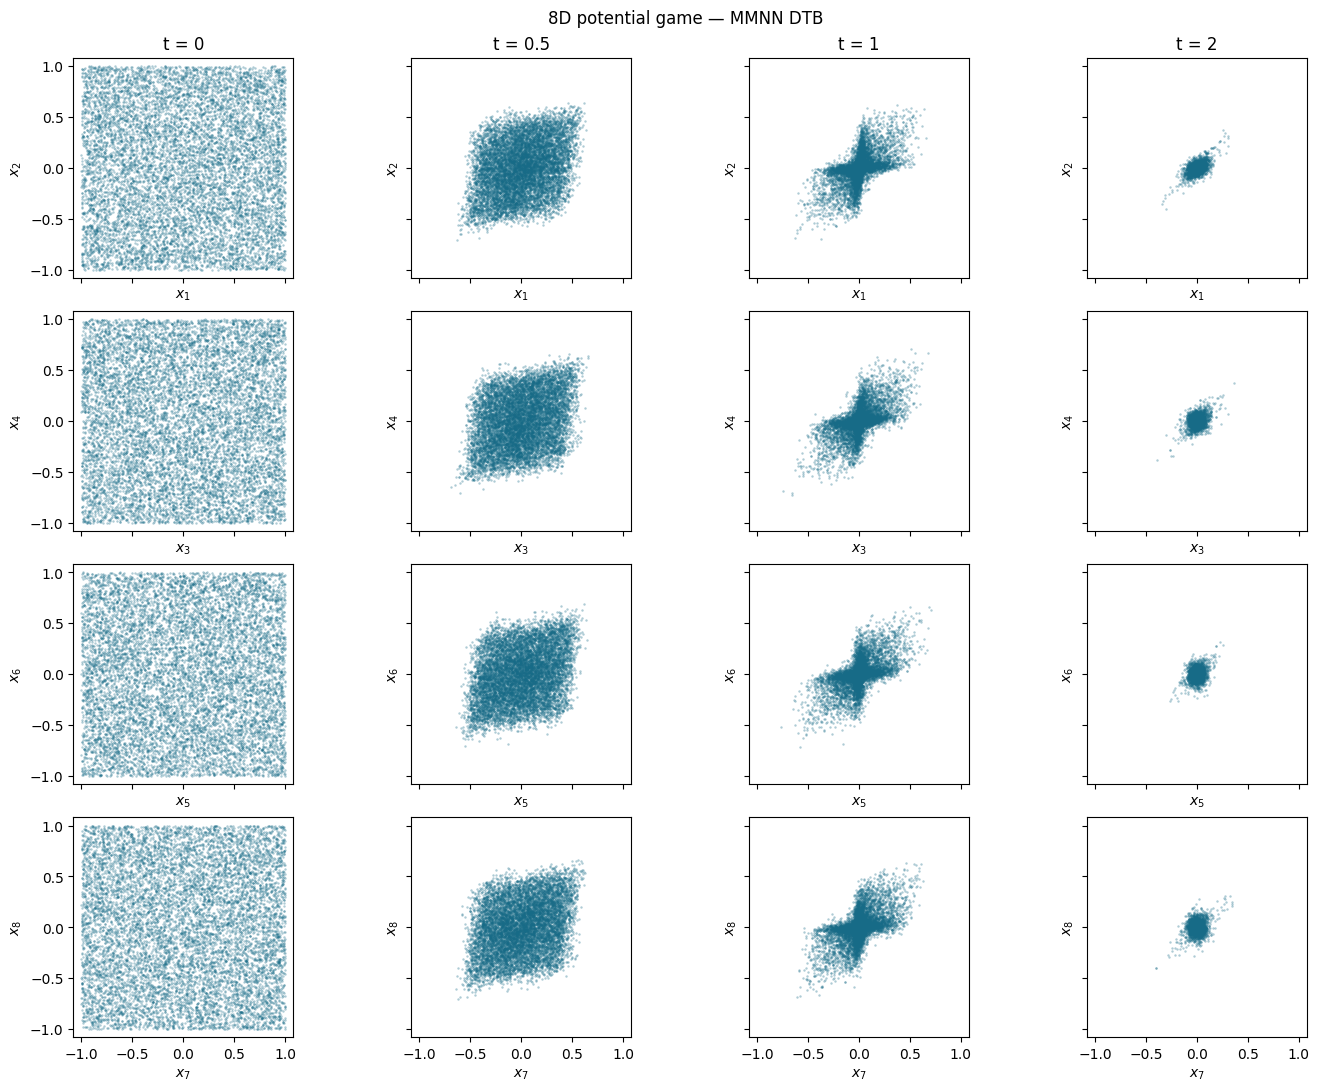

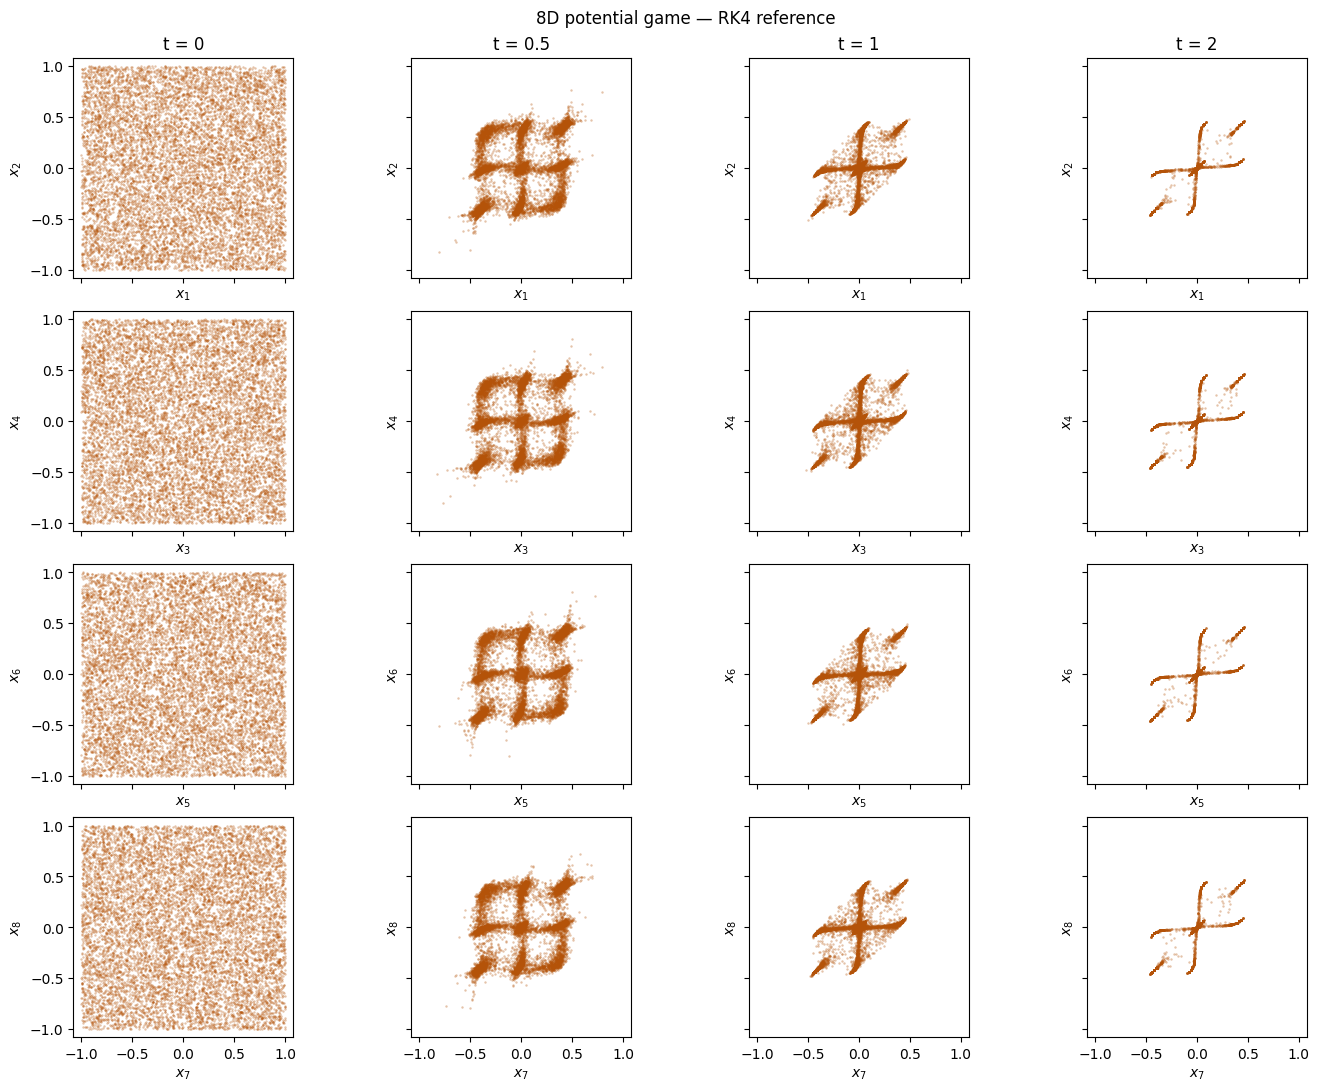

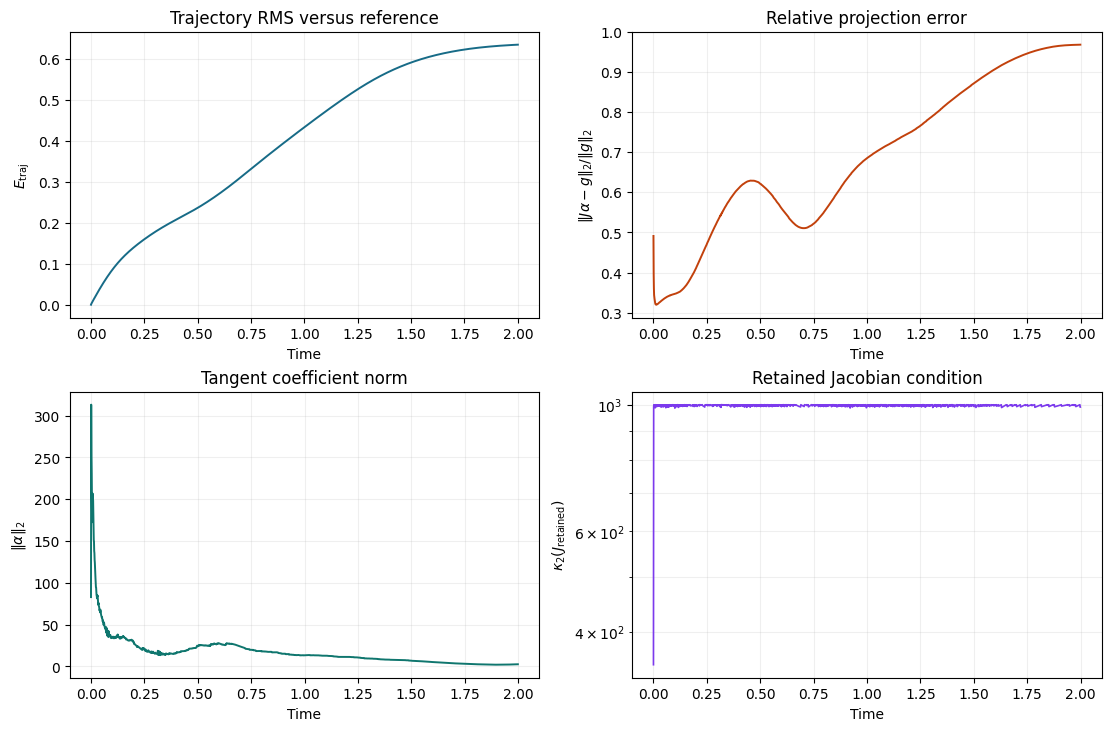

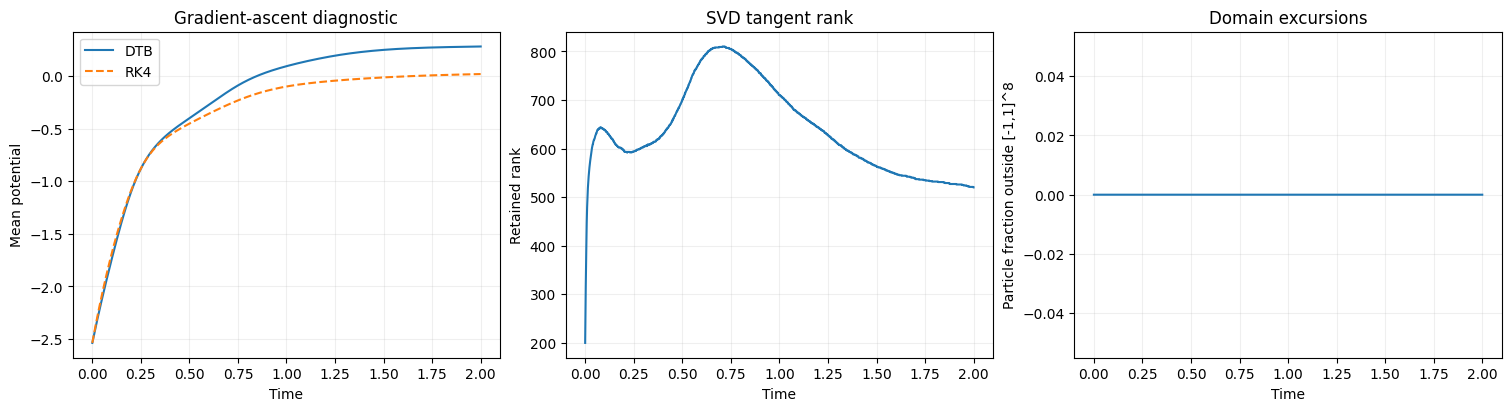

In [8]:
COORDINATE_PAIRS = [(1, 2), (3, 4), (5, 6), (7, 8)]  # one-based indices
for snapshots, label, color in ((dtb_snapshots, "MMNN DTB", "#176b87"),
                                 (reference_snapshots, "RK4 reference", "#b45309")):
    plot_cloud_snapshots(snapshots, coordinate_pairs=COORDINATE_PAIRS,
                         title=f"8D potential game — {label}", color=color,
                         output_path=run_dir / ("dtb_clouds.png" if label == "MMNN DTB"
                                                 else "rk4_clouds.png"))
    plt.show()

plot_configuration_diagnostics(
    times, state_diagnostics[:, 1], times[:-1], diagnostics[:, 2], diagnostics[:, 3],
    diagnostics[:, 5], output_path=run_dir / "configuration_diagnostics.png",
)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout="constrained")
axes[0].plot(times, state_diagnostics[:, 2], label="DTB")
axes[0].plot(times, state_diagnostics[:, 3], "--", label="RK4")
axes[0].set(ylabel="Mean potential", title="Gradient-ascent diagnostic")
axes[0].legend()
axes[1].plot(times[:-1], diagnostics[:, 4])
axes[1].set(ylabel="Retained rank", title="SVD tangent rank")
axes[2].plot(times, state_diagnostics[:, 4])
axes[2].set(ylabel="Particle fraction outside [-1,1]^8", title="Domain excursions")
for axis in axes:
    axis.set_xlabel("Time")
    axis.grid(alpha=0.2)
fig.savefig(run_dir / "potential_rank_domain.png", dpi=200, bbox_inches="tight")
plt.show()


## Archive results 

Run the final cell to create a ZIP containing the map checkpoint, numerical
arrays, configuration, and plots. In JupyterLab's file browser, navigate to the
printed directory, right-click the ZIP, and select **Download**.


In [9]:
archive = shutil.make_archive(str(run_dir), "zip", root_dir=run_dir)
print("Results folder:", run_dir)
print("Results archive:", archive)
print("Download this ZIP using the JupyterLab file browser.")


Results folder: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/potential_game_8d_mmnn/20260921T020056_014780Z
Results archive: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/potential_game_8d_mmnn/20260921T020056_014780Z.zip
Download this ZIP using the PACE JupyterLab file browser.
